In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import hwostyle
hwostyle.use("light")

from san import (
    CoronagraphModel,
    SpeckleAreaNulling,
    MinStepNulling,
    LagStepNulling
)

/opt/anaconda3/envs/san/lib/python3.11/site-packages/hcipy/optics/aberration.py:38: RuntimeWarning: divide by zero encountered in power
  res = Field(grid.as_('polar').r**exponent, grid)


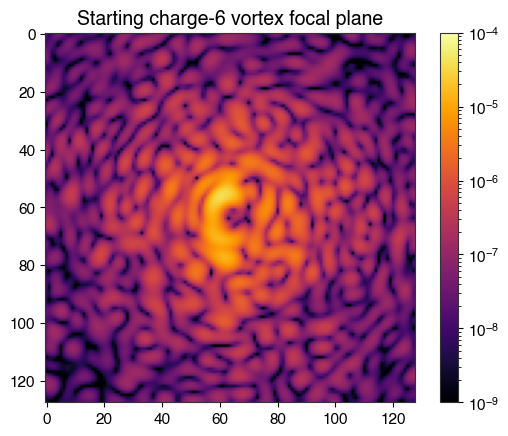

In [18]:
# init model 
model = CoronagraphModel(iwa_ld=1, owa_ld=14, seed=1)
dz_mask = model.dz_mask
img_initial = model.image()
SAN_WARMUP_GAIN = 1.

norm = LogNorm(vmin=1e-9, vmax=1e-4)
plt.figure()
plt.title("Starting charge-6 vortex focal plane")
plt.imshow(img_initial, cmap="inferno",norm=norm)
plt.colorbar()
plt.show()

# Testing SNF with our warm-up SAN iteration

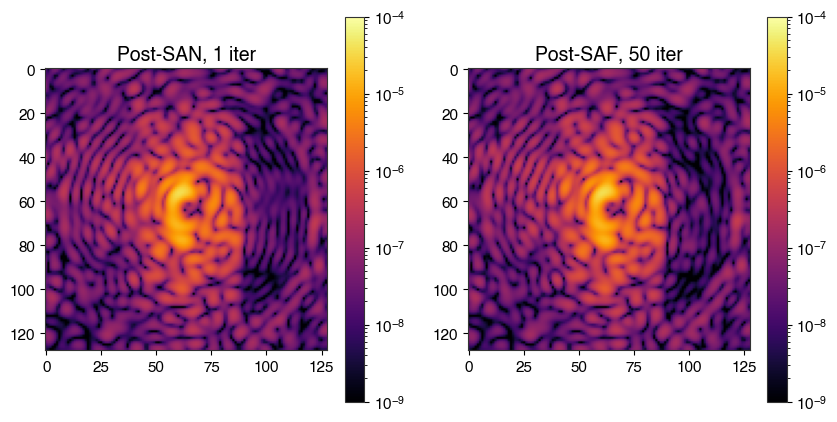

In [19]:
SAN_ITERS = 1
SAF_ITERS = 50
# Init furious nuller
nuller = MinStepNulling(model, forget=1)
snf_contrast_history = [nuller.contrast]
snf_exposure_history = [0]


# warm up with SAN steps
for i in range(SAN_ITERS):
    nuller.san_step(gain=SAN_WARMUP_GAIN)
    snf_contrast_history.append(nuller.contrast)
    snf_exposure_history.append(snf_exposure_history[-1] + 5) 

post_san = nuller.last_image

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title(f"Post-SAN, {SAN_ITERS} iter")
plt.imshow(post_san, cmap="inferno", norm=norm)
plt.colorbar()

# run furious steps
for i in range(SAF_ITERS):
    nuller.furious_step()
    snf_contrast_history.append(nuller.contrast)
    snf_exposure_history.append(snf_exposure_history[-1] + 1)

post_saf = nuller.last_image

plt.subplot(122)
plt.title(F"Post-SAF, {SAF_ITERS} iter")
plt.imshow(post_saf, cmap="inferno", norm=norm)
plt.colorbar()

# Test SAN by itself
4-probe 1-reference speckle suppression

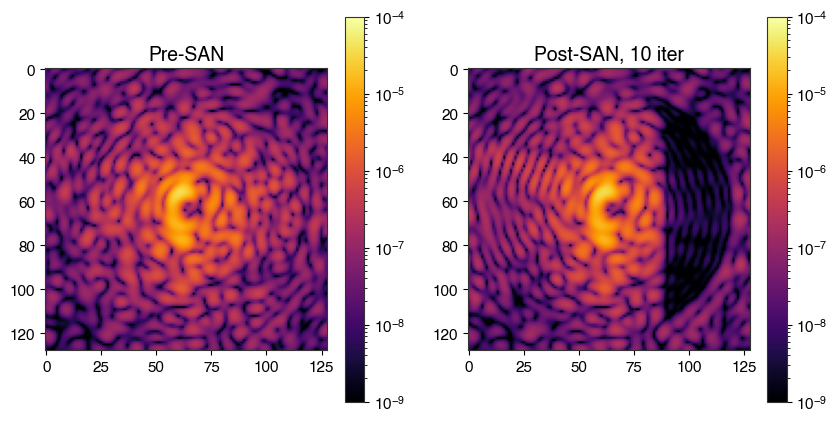

In [20]:
SAN_ITERS = 10
# Init furious nuller
nuller = MinStepNulling(model, forget=1)
san_contrast_history = [nuller.contrast]
san_exposure_history = [0]


pre_san = nuller.last_image

# warm up with SAN steps
nuller.san_step(gain=SAN_WARMUP_GAIN)
san_contrast_history.append(nuller.contrast)
san_exposure_history.append(san_exposure_history[-1] + 5) 

for i in range(SAN_ITERS-1):
    nuller.san_step(gain=1)
    san_contrast_history.append(nuller.contrast)
    san_exposure_history.append(san_exposure_history[-1] + 5) 


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title(f"Pre-SAN")
plt.imshow(pre_san, cmap="inferno", norm=norm)
plt.colorbar()

post_san = nuller.last_image

plt.subplot(122)
plt.title(F"Post-SAN, {SAN_ITERS} iter")
plt.imshow(post_san, cmap="inferno", norm=norm)
plt.colorbar()

# Test Minstep
2-probe 1-reference speckle supression

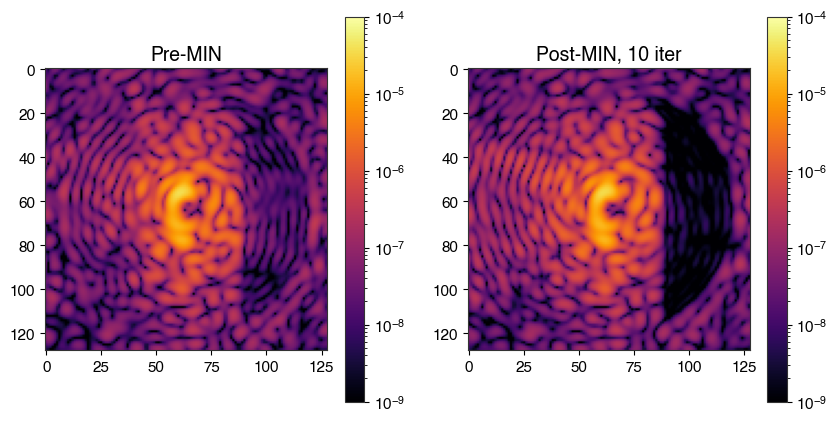

In [21]:
MIN_ITERS = 10
# Init furious nuller
nuller = MinStepNulling(model)
min_contrast_history = [nuller.contrast]
min_exposure_history = [0]



# Warm up with SAN step
for i in range(1):
    nuller.san_step(gain=SAN_WARMUP_GAIN)
    min_contrast_history.append(nuller.contrast)
    min_exposure_history.append(min_exposure_history[-1] + 5)

pre_min = nuller.last_image

# warm up with SAN steps
for i in range(MIN_ITERS):
    nuller.min_step()
    min_contrast_history.append(nuller.contrast)
    min_exposure_history.append(min_exposure_history[-1] + 3) 


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title(f"Pre-MIN")
plt.imshow(pre_min, cmap="inferno", norm=norm)
plt.colorbar()

post_min = nuller.last_image

plt.subplot(122)
plt.title(F"Post-MIN, {MIN_ITERS} iter")
plt.imshow(post_min, cmap="inferno", norm=norm)
plt.colorbar()

# Test Lagstep
1-probe, 1-reference, alternate SIN/COS probes

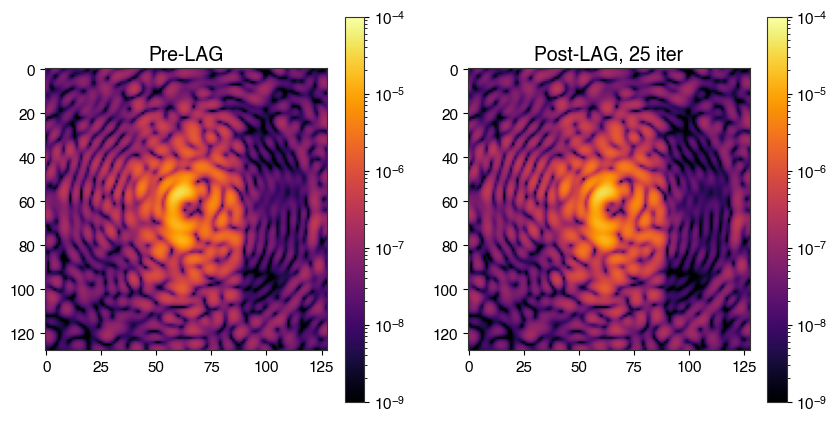

In [22]:
LAG_ITERS = 25
# Init furious nuller
nuller = LagStepNulling(model, forget=1, eps=0.5)
lag_contrast_history = [nuller.contrast]
lag_exposure_history = [0]



# Warm up with SAN step
for i in range(1):
    nuller.san_step(gain=SAN_WARMUP_GAIN)
    lag_contrast_history.append(nuller.contrast)
    lag_exposure_history.append(lag_exposure_history[-1] + 5)

pre_lag = nuller.last_image

# warm up with SAN steps
for i in range(LAG_ITERS):
    nuller.lag_step()
    lag_contrast_history.append(nuller.contrast)
    lag_exposure_history.append(lag_exposure_history[-1] + 2) 


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title(f"Pre-LAG")
plt.imshow(pre_lag, cmap="inferno", norm=norm)
plt.colorbar()

post_lag = nuller.last_image

plt.subplot(122)
plt.title(F"Post-LAG, {LAG_ITERS} iter")
plt.imshow(post_lag, cmap="inferno", norm=norm)
plt.colorbar()

# Algorithm Efficiency comparison

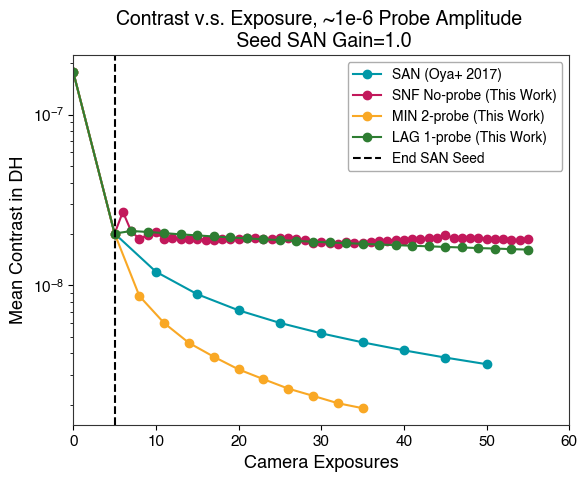

In [23]:
plt.figure()
plt.title(f"Contrast v.s. Exposure, ~1e-6 Probe Amplitude \n Seed SAN Gain={SAN_WARMUP_GAIN}")
plt.plot(san_exposure_history, san_contrast_history, marker="o", label="SAN (Oya+ 2017)")
plt.plot(snf_exposure_history, snf_contrast_history, marker="o", label="SNF No-probe (This Work)")
plt.plot(min_exposure_history, min_contrast_history, marker="o", label="MIN 2-probe (This Work)")
plt.plot(lag_exposure_history, lag_contrast_history, marker="o", label="LAG 1-probe (This Work)")
plt.yscale("log")
plt.ylabel("Mean Contrast in DH")
plt.xlabel("Camera Exposures")
plt.axvline(5, linestyle="dashed", color="k", label="End SAN Seed")
plt.xlim(0, 60)
plt.legend()
plt.show()


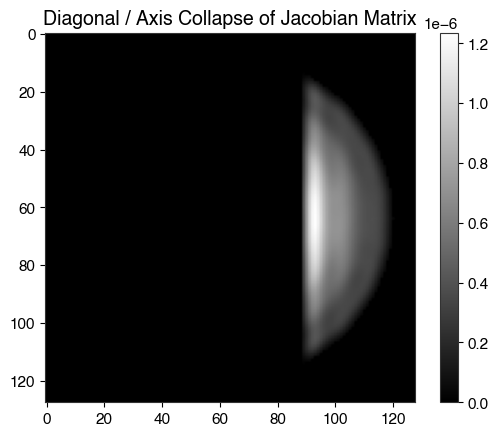

In [24]:
jacobian = np.zeros([128, 128])
jacobian[nuller.dz] = nuller.kappa_cos
plt.figure()
plt.title("Diagonal / Axis Collapse of Jacobian Matrix")
plt.imshow(jacobian, cmap="gray", norm=None)
plt.colorbar()
plt.show()
